# SIMULASI SKENARIO KEBIJAKAN — 23 RUN

Mengikuti protokol skenario final yang sudah dikunci.

**Dua tuas kebijakan:** Insentif Kebijakan dan Kebijakan Konservasi Lahan.

| Kode | Skenario | Insentif | Konservasi |
|---|---|---|---|
| S1 | Business-as-Usual | 0 | 0 |
| S2 | Sustainable | 0,1 | 1,0 |
| S3 | Development Priority | 0,3 | 0 |

**Matriks run:** 3 skenario × 7 kondisi (C0 nilai final, C1–C2 rasio LPD/LPE, C3–C4 bobot Daya Tarik,
C5–C6 Laju Konversi Dasar) = 21 run, ditambah 2 run dekomposisi (D1 Insentif saja, D2 Konservasi saja)
pada kondisi C0 = **23 run**.

**File yang diperlukan:** `MODEL_SISTEM_DINAMIS.mdl` versi final — LPE 0,27726; LPD 0,207945;
Laju Konversi Dasar 0,0436052; TPK Ambang 0,275; Laju Demolisi 0,05; Sensitivitas Konstruksi 2,31385;
kedua tuas bernilai 0.

In [4]:
!pip install pysd openpyxl matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 32.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[04] Simulasi Skenario")
FILE = FOLDER / "MODEL SISTEM DINAMIS.mdl"
FOLDER.mkdir(parents=True, exist_ok=True)
if not FILE.exists():
    from google.colab import files
    print(f"'{FILE.name}' belum ada, silakan upload:"); files.upload()

LUAS, KEP_REF = 317036.0, 128.363          # luas wilayah DIY, Kepadatan Referensi 2025

model = pysd.read_vensim(str(FILE))
TPK       = [k for k in model.namespace if "TPK" in k and "Ambang" not in k][0]
ODTW_FLOW = [k for k in model.namespace if "Pembangunan" in k and "ODTW" in k][0]

VAR = ["Jumlah Wisatawan","Jumlah Hotel dan Akomodasi","Jumlah Objek Daya Tarik Wisata",
       "Tenaga Kerja Pariwisata","Lahan Terbangun","Daya Tarik Destinasi Wisata","Kepadatan Wisatawan",
       "Rasio Daya Dukung Lahan","Pengeluaran Wisatawan","PDRB Sektor Pariwisata",
       "Investasi Sektor Pariwisata","Total Malam Menginap","Rasio Permintaan terhadap Kapasitas Kamar",
       TPK,"Intensitas Tenaga Kerja","Tenaga Kerja Dibutuhkan","Laju Kedatangan Wisatawan",
       "Laju Penurunan Wisatawan","Laju Konstruksi Hotel dan Akomodasi","Laju Demolisi Hotel dan Akomodasi",
       ODTW_FLOW,"Laju Penutupan ODTW","Laju Penyerapan Tenaga Kerja Pariwisata",
       "Laju Keluar Tenaga Kerja Pariwisata","Laju Konversi Lahan Pariwisata","Laju Konversi Lahan Non Pariwisata"]
BERSIH = [v.strip('"') for v in VAR]

## Definisi skenario, kondisi kekokohan, dan dekomposisi

In [6]:
SKENARIO = {"S1 BAU":(0.0, 0.0), "S2 Sustainable":(0.1, 1.0), "S3 Development Priority":(0.3, 0.0)}

KONDISI = {
 "C0 nilai final": {},
 "C1 rasio LPD/LPE 0,65": {"Laju Penurunan Dasar": 0.65*0.27726},   # LPE tetap, hanya rasio berubah
 "C2 rasio LPD/LPE 0,90": {"Laju Penurunan Dasar": 0.90*0.27726},
 "C3 bobot 0,50/0,25/0,25": {"Bobot ODTW":0.50, "Bobot Kepadatan":0.25, "Bobot Daya Dukung Lahan":0.25,
                             "Laju Pertumbuhan Eksternal":0.274467, "Laju Penurunan Dasar":0.205850},
 "C4 bobot 0,30/0,45/0,25": {"Bobot ODTW":0.30, "Bobot Kepadatan":0.45, "Bobot Daya Dukung Lahan":0.25,
                             "Laju Pertumbuhan Eksternal":0.280112, "Laju Penurunan Dasar":0.210084},
 "C5 konversi 0,0034118": {"Laju Konversi Dasar": 0.0034118},       # batas bawah CI 95% LOGEST
 "C6 konversi 0,0851069": {"Laju Konversi Dasar": 0.0851069},       # batas atas CI 95% LOGEST
}

DEKOMPOSISI = {"D1 Insentif saja":(0.1, 0.0), "D2 Konservasi saja":(0.0, 1.0)}   # hanya pada C0

def jalankan(insentif, konservasi, kondisi=None):
    m = pysd.read_vensim(str(FILE))
    p = {"Insentif Kebijakan": insentif, "Kebijakan Konservasi Lahan": konservasi}
    p.update(kondisi or {})
    r = m.run(params=p, return_columns=VAR, return_timestamps=list(range(2025, 2051)))
    r = r.apply(lambda s: np.real(s.astype(complex))); r.columns = BERSIH
    return r

## KPI, arah interpretasi, dan ambang

Arah `deskriptif` dan `dilaporkan` tidak diperingkat dan tidak dinilai baik atau buruk.

In [7]:
KPI = [
 ("Lapangan kerja pariwisata 2050 (jiwa)",      lambda r: r["Tenaga Kerja Pariwisata"][2050],            "maks", None),
 ("PDRB pariwisata 2050 (miliar Rp)",           lambda r: r["PDRB Sektor Pariwisata"][2050],             "maks", None),
 ("Investasi kumulatif 2025-2050 (miliar Rp)",  lambda r: r["Investasi Sektor Pariwisata"].sum(),        "deskriptif", None),
 ("TPK 2050",                                   lambda r: r[TPK.strip('"')][2050],                       "deskriptif", None),
 ("RDDL 2050",                                  lambda r: r["Rasio Daya Dukung Lahan"][2050],            "maks", (">", 0.331)),
 ("Lahan terbangun 2050 (ha)",                  lambda r: r["Lahan Terbangun"][2050],                    "min",  None),
 ("Konversi lahan pariwisata kumulatif (ha)",   lambda r: r["Laju Konversi Lahan Pariwisata"].sum(),     "min",  None),
 ("Indeks kepadatan 2050",                      lambda r: r["Kepadatan Wisatawan"][2050]/KEP_REF,        "min",  ("<", 2.0)),
 ("Daya Tarik 2050",                            lambda r: r["Daya Tarik Destinasi Wisata"][2050],        "maks", None),
 ("Jumlah wisatawan 2050",                      lambda r: r["Jumlah Wisatawan"][2050],                   "dilaporkan", None),
 ("Jumlah hotel 2050",                          lambda r: r["Jumlah Hotel dan Akomodasi"][2050],         "deskriptif", None),
 ("Jumlah ODTW 2050",                           lambda r: r["Jumlah Objek Daya Tarik Wisata"][2050],     "deskriptif", None),
]
NAMA_KPI = [k[0] for k in KPI]

## Jalankan 23 run

In [8]:
hasil, seri = [], {}

for kk, kp in KONDISI.items():
    for sk, (ins, kons) in SKENARIO.items():
        r = jalankan(ins, kons, kp); seri[(kk, sk)] = r
        baris = {"Kondisi":kk, "Skenario":sk, "Insentif":ins, "Konservasi":kons}
        for nama, f, arah, amb in KPI: baris[nama] = f(r)
        for v in BERSIH: baris[f"[lampiran] {v} 2050"] = r[v][2050]
        hasil.append(baris)

for dk, (ins, kons) in DEKOMPOSISI.items():
    r = jalankan(ins, kons); seri[("C0 nilai final", dk)] = r
    baris = {"Kondisi":"C0 nilai final", "Skenario":dk, "Insentif":ins, "Konservasi":kons}
    for nama, f, arah, amb in KPI: baris[nama] = f(r)
    for v in BERSIH: baris[f"[lampiran] {v} 2050"] = r[v][2050]
    hasil.append(baris)

H = pd.DataFrame(hasil)
print(f"{len(H)} run selesai (harus 23).")

23 run selesai (harus 23).


## Tabel 2 — KPI 2050 dan selisih terhadap BAU

In [9]:
c0 = H[(H.Kondisi=="C0 nilai final") & (H.Skenario.isin(SKENARIO))].set_index("Skenario")
t2 = pd.DataFrame(index=NAMA_KPI)
for sk in SKENARIO: t2[sk] = [c0.loc[sk, k] for k in NAMA_KPI]
for sk in list(SKENARIO)[1:]:
    t2[f"{sk} vs BAU (%)"] = 100*(t2[sk]-t2["S1 BAU"])/t2["S1 BAU"]
t2["Arah"]   = [k[2] for k in KPI]
t2["Ambang"] = [f"{k[3][0]} {k[3][1]}" if k[3] else "-" for k in KPI]
display(t2.round(4))

print("Status ambang:")
for nama, f, arah, amb in KPI:
    if amb:
        op, nilai = amb
        for sk in SKENARIO:
            v = c0.loc[sk, nama]
            ok = v > nilai if op == ">" else v < nilai
            print(f"  {nama:<42}{sk:<26}{v:10.4f}  {op} {nilai}  -> {'LOLOS' if ok else 'TIDAK LOLOS'}")

,S1 BAU,S2 Sustainable,S3 Development Priority,S2 Sustainable vs BAU (%),S3 Development Priority vs BAU (%),Arah,Ambang
Lapangan kerja pariwisata 2050 (jiwa),6.503552e+05,6.674584e+05,6.970213e+05,2.6298,7.1755,maks,-
PDRB pariwisata 2050 (miliar Rp),4.006110e+04,4.119382e+04,4.315166e+04,2.8275,7.7146,maks,-
Investasi kumulatif 2025-2050 (miliar Rp),3.731755e+04,4.154984e+04,5.013284e+04,11.3413,34.3412,deskriptif,-
TPK 2050,3.584000e-01,3.537000e-01,3.458000e-01,-1.3032,-3.5035,deskriptif,-
RDDL 2050,6.145000e-01,6.180000e-01,6.140000e-01,0.5718,-0.0868,maks,> 0.331
Lahan terbangun 2050 (ha),1.222076e+05,1.210936e+05,1.223767e+05,-0.9116,0.1383,min,-
Konversi lahan pariwisata kumulatif (ha),9.470196e+02,0.000000e+00,1.095105e+03,-100.0000,15.6370,min,-
Indeks kepadatan 2050,2.363800e+00,2.430700e+00,2.546200e+00,2.8275,7.7146,min,< 2.0
Daya Tarik 2050,8.132000e-01,8.205000e-01,8.322000e-01,0.8937,2.3319,maks,-
Jumlah wisatawan 2050,9.619715e+07,9.891713e+07,1.036184e+08,2.8275,7.7146,dilaporkan,-


Status ambang:
  RDDL 2050                                 S1 BAU                        0.6145  > 0.331  -> LOLOS
  RDDL 2050                                 S2 Sustainable                0.6180  > 0.331  -> LOLOS
  RDDL 2050                                 S3 Development Priority       0.6140  > 0.331  -> LOLOS
  Indeks kepadatan 2050                     S1 BAU                        2.3638  < 2.0  -> TIDAK LOLOS
  Indeks kepadatan 2050                     S2 Sustainable                2.4307  < 2.0  -> TIDAK LOLOS
  Indeks kepadatan 2050                     S3 Development Priority       2.5462  < 2.0  -> TIDAK LOLOS


## Tabel 3 — peringkat, dan Tabel 4 — dekomposisi tuas

In [10]:
rank_kpi = [k for k in KPI if k[2] in ("maks","min")]
t3 = pd.DataFrame(index=[k[0] for k in rank_kpi])
for sk in SKENARIO: t3[sk] = [c0.loc[sk, k[0]] for k in rank_kpi]
for nama, f, arah, amb in rank_kpi:
    urut = t3.loc[nama, list(SKENARIO)].rank(ascending=(arah=="min")).astype(int)
    for sk in SKENARIO: t3.loc[nama, f"Peringkat {sk}"] = urut[sk]
display(t3[[f"Peringkat {s}" for s in SKENARIO]].astype(int))

d = H[H.Kondisi=="C0 nilai final"].set_index("Skenario")
t4 = pd.DataFrame(index=NAMA_KPI)
for lab in ["S1 BAU","D1 Insentif saja","D2 Konservasi saja","S2 Sustainable"]:
    t4[lab] = [d.loc[lab, k] for k in NAMA_KPI]
t4["Kontribusi Insentif"]   = t4["D1 Insentif saja"]  - t4["S1 BAU"]
t4["Kontribusi Konservasi"] = t4["D2 Konservasi saja"]- t4["S1 BAU"]
t4["Selisih paket S2"]      = t4["S2 Sustainable"]    - t4["S1 BAU"]
t4["Efek interaksi"]        = t4["Selisih paket S2"] - t4["Kontribusi Insentif"] - t4["Kontribusi Konservasi"]
display(t4[["Kontribusi Insentif","Kontribusi Konservasi","Selisih paket S2","Efek interaksi"]].round(3))

,Peringkat S1 BAU,Peringkat S2 Sustainable,Peringkat S3 Development Priority
Lapangan kerja pariwisata 2050 (jiwa),3,2,1
PDRB pariwisata 2050 (miliar Rp),3,2,1
RDDL 2050,2,1,3
Lahan terbangun 2050 (ha),2,1,3
Konversi lahan pariwisata kumulatif (ha),2,1,3
Indeks kepadatan 2050,1,2,3
Daya Tarik 2050,3,2,1


,Kontribusi Insentif,Kontribusi Konservasi,Selisih paket S2,Efek interaksi
Lapangan kerja pariwisata 2050 (jiwa),15526.237,1458.692,17103.149,118.220
PDRB pariwisata 2050 (miliar Rp),1026.254,98.238,1132.727,8.234
Investasi kumulatif 2025-2050 (miliar Rp),4190.421,35.469,4232.288,6.399
TPK 2050,-0.005,0.000,-0.005,-0.000
RDDL 2050,-0.000,0.004,0.004,0.000
Lahan terbangun 2050 (ha),57.562,-1114.030,-1114.030,-57.562
Konversi lahan pariwisata kumulatif (ha),50.129,-947.020,-947.020,-50.129
Indeks kepadatan 2050,0.061,0.006,0.067,0.000
Daya Tarik 2050,0.006,0.001,0.007,0.000
Jumlah wisatawan 2050,2464304.775,235895.888,2719973.262,19772.599


## Tabel 5 — matriks kekokohan

Peringkat dinyatakan kokoh bila urutan skenario tidak berubah di ketujuh kondisi.
Perubahan besaran selisih tidak membatalkan kekokohan.

In [11]:
t5 = pd.DataFrame(index=[k[0] for k in rank_kpi], columns=list(KONDISI))
for kk in KONDISI:
    sub = H[(H.Kondisi==kk) & (H.Skenario.isin(SKENARIO))].set_index("Skenario")
    for nama, f, arah, amb in rank_kpi:
        urut = sub[nama].sort_values(ascending=(arah=="min")).index.tolist()
        t5.loc[nama, kk] = " > ".join(s.split()[0] for s in urut)
t5["Kokoh?"] = ["KOKOH" if t5.loc[i].nunique()==1 else "BERUBAH" for i in t5.index]
display(t5)

,C0 nilai final,"C1 rasio LPD/LPE 0,65","C2 rasio LPD/LPE 0,90","C3 bobot 0,50/0,25/0,25","C4 bobot 0,30/0,45/0,25","C5 konversi 0,0034118","C6 konversi 0,0851069",Kokoh?
Lapangan kerja pariwisata 2050 (jiwa),S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,KOKOH
PDRB pariwisata 2050 (miliar Rp),S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,KOKOH
RDDL 2050,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,KOKOH
Lahan terbangun 2050 (ha),S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,KOKOH
Konversi lahan pariwisata kumulatif (ha),S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,S2 > S1 > S3,KOKOH
Indeks kepadatan 2050,S1 > S2 > S3,S1 > S2 > S3,S1 > S2 > S3,S1 > S2 > S3,S1 > S2 > S3,S1 > S2 > S3,S1 > S2 > S3,KOKOH
Daya Tarik 2050,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,S3 > S2 > S1,KOKOH


## Grafik lintasan 2025–2050

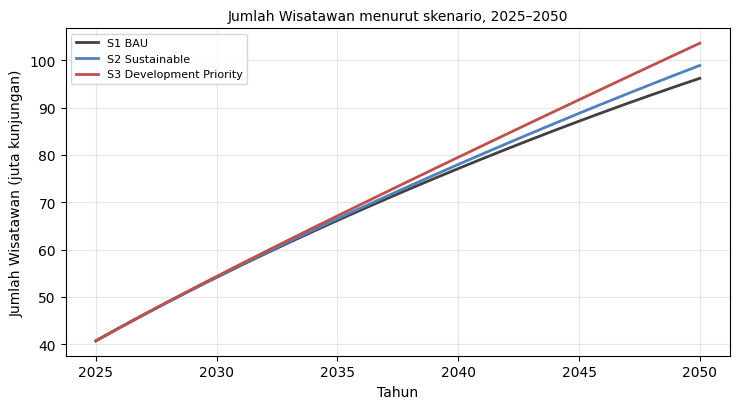

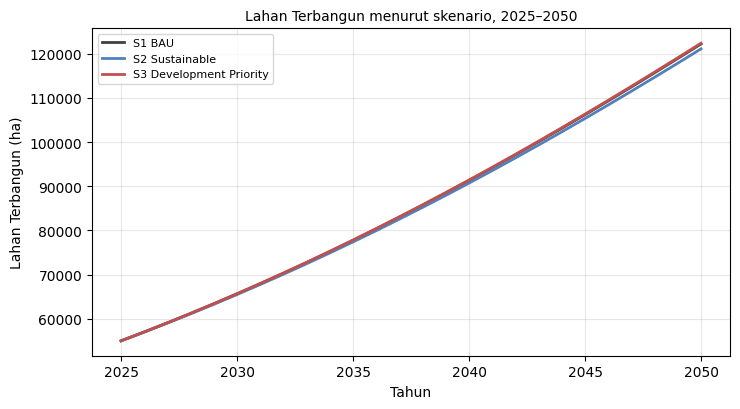

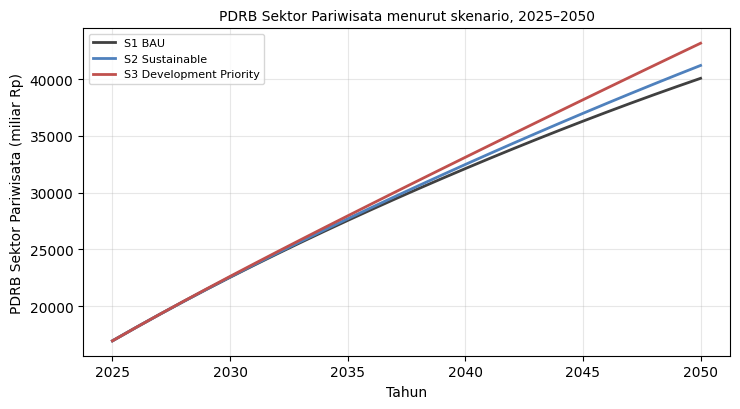

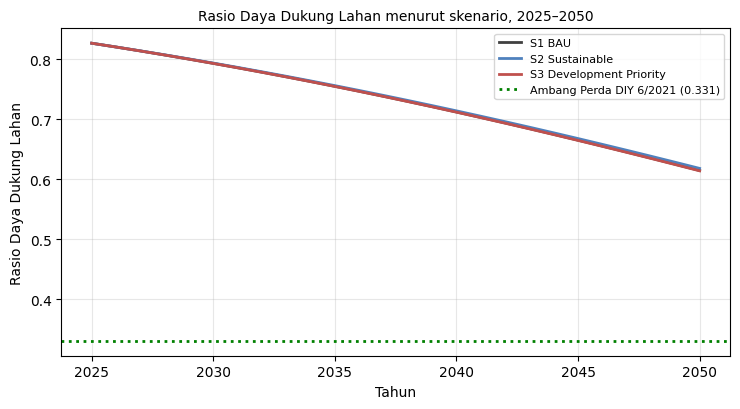

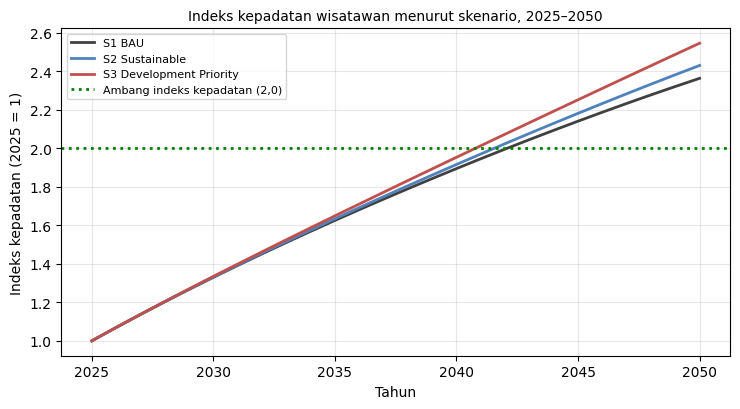

In [12]:
GRAFIK = [("Jumlah Wisatawan", "Kunjungan", 1e6, "juta kunjungan", None),
          ("Lahan Terbangun", "Hektar", 1, "ha", None),
          ("PDRB Sektor Pariwisata", "Miliar Rupiah", 1, "miliar Rp", None),
          ("Rasio Daya Dukung Lahan", "Dmnl", 1, "", 0.331)]
WARNA = {"S1 BAU":"#404040", "S2 Sustainable":"#4f81bd", "S3 Development Priority":"#c0504d"}

for var, _, skala, satuan, ambang in GRAFIK:
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    for sk in SKENARIO:
        r = seri[("C0 nilai final", sk)]
        ax.plot(r.index, r[var]/skala, lw=2, color=WARNA[sk], label=sk)
    if ambang is not None:
        ax.axhline(ambang, color="green", ls=":", lw=2, label=f"Ambang Perda DIY 6/2021 ({ambang})")
    ax.set_xlabel("Tahun"); ax.set_ylabel(f"{var} ({satuan})" if satuan else var)
    ax.set_title(f"{var} menurut skenario, 2025–2050", fontsize=10)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.tight_layout(); fig.savefig(FOLDER / f"skenario_{var.replace(' ','_')}.png", dpi=150); plt.show()

# indeks kepadatan dengan garis ambang 2,0
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for sk in SKENARIO:
    r = seri[("C0 nilai final", sk)]
    ax.plot(r.index, r["Kepadatan Wisatawan"]/KEP_REF, lw=2, color=WARNA[sk], label=sk)
ax.axhline(2.0, color="green", ls=":", lw=2, label="Ambang indeks kepadatan (2,0)")
ax.set_xlabel("Tahun"); ax.set_ylabel("Indeks kepadatan (2025 = 1)")
ax.set_title("Indeks kepadatan wisatawan menurut skenario, 2025–2050", fontsize=10)
ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FOLDER / "skenario_Indeks_Kepadatan.png", dpi=150); plt.show()

In [13]:
# ---------- Tahun ambang indeks kepadatan terlampaui ----------
AMBANG_KEPADATAN = 2.0
baris = []
for sk in SKENARIO:
    r = seri[("C0 nilai final", sk)]
    idx = r["Kepadatan Wisatawan"]/KEP_REF
    lewat = idx[idx > AMBANG_KEPADATAN]
    baris.append({"Skenario": sk,
                  "Tahun ambang 2,0 terlampaui": int(lewat.index[0]) if len(lewat) else "tidak terlampaui",
                  "Indeks kepadatan 2050": idx[2050]})
tahun_ambang = pd.DataFrame(baris)
display(tahun_ambang.round(4))

# ---------- Komposisi Daya Tarik 2050 ----------
B_ODTW, B_KEP, B_LAHAN = 0.40, 0.35, 0.25
ELAS, BATAS = 0.3, 1.5
ODTW_REF, RDDL_REF = 201.0, 0.826425

baris = []
for sk in SKENARIO:
    r = seri[("C0 nilai final", sk)]
    k_odtw  = B_ODTW  * min(BATAS, (r["Jumlah Objek Daya Tarik Wisata"][2050]/ODTW_REF)**ELAS)
    k_kep   = B_KEP   * min(1.0, KEP_REF/r["Kepadatan Wisatawan"][2050])
    k_lahan = B_LAHAN * (r["Rasio Daya Dukung Lahan"][2050]/RDDL_REF)
    baris.append({"Skenario":sk, "Komponen ODTW":k_odtw, "Komponen kepadatan":k_kep,
                  "Komponen lahan":k_lahan, "Jumlah komponen":k_odtw+k_kep+k_lahan,
                  "Daya Tarik model":r["Daya Tarik Destinasi Wisata"][2050]})
komposisi = pd.DataFrame(baris).set_index("Skenario")
display(komposisi.round(4))

# cek: jumlah komponen harus sama dengan Daya Tarik keluaran model
selisih = (komposisi["Jumlah komponen"] - komposisi["Daya Tarik model"]).abs().max()
print(f"Selisih maksimum jumlah komponen vs keluaran model: {selisih:.6f}")

,Skenario,"Tahun ambang 2,0 terlampaui",Indeks kepadatan 2050
0,S1 BAU,2043,2.3638
1,S2 Sustainable,2042,2.4307
2,S3 Development Priority,2041,2.5462


,Komponen ODTW,Komponen kepadatan,Komponen lahan,Jumlah komponen,Daya Tarik model
Skenario,,,,,
S1 BAU,0.4793,0.1481,0.1859,0.8132,0.8132
S2 Sustainable,0.4896,0.1440,0.1870,0.8205,0.8205
S3 Development Priority,0.5090,0.1375,0.1857,0.8322,0.8322


Selisih maksimum jumlah komponen vs keluaran model: 0.000000


## Simpan Excel

In [14]:
berkas = FOLDER / "hasil_simulasi_skenario.xlsx"
with pd.ExcelWriter(berkas) as w:
    pd.DataFrame([{"Skenario":s, "Insentif":v[0], "Konservasi":v[1]} for s, v in SKENARIO.items()]
                 ).to_excel(w, sheet_name="Tabel 1 Skenario", index=False)
    t2.round(6).to_excel(w, sheet_name="Tabel 2 KPI dan Selisih")
    t3.round(6).to_excel(w, sheet_name="Tabel 3 Peringkat")
    t4.round(6).to_excel(w, sheet_name="Tabel 4 Dekomposisi")
    t5.to_excel(w, sheet_name="Tabel 5 Kekokohan")
    tahun_ambang.round(4).to_excel(w, sheet_name="Tahun Ambang Kepadatan", index=False)
    komposisi.round(6).to_excel(w, sheet_name="Komposisi Daya Tarik")
    H[["Kondisi","Skenario","Insentif","Konservasi"]+NAMA_KPI].round(6).to_excel(
        w, sheet_name="KPI seluruh run", index=False)
    H[["Kondisi","Skenario"]+[c for c in H.columns if c.startswith("[lampiran]")]].round(4).to_excel(
        w, sheet_name="Lampiran 26 variabel", index=False)
    for (kk, sk), r in seri.items():
        if kk == "C0 nilai final":
            r.round(4).to_excel(w, sheet_name=f"Seri {sk.split()[0]}"[:31])
print("Tersimpan:", berkas)

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[04] Simulasi Skenario/hasil_simulasi_skenario.xlsx


## Angka untuk pencocokan (kondisi C0)

| KPI | S1 BAU | S2 Sustainable | S3 Development Priority |
|---|---|---|---|
| Lapangan kerja (jiwa) | 650.355 | 667.458 | 697.021 |
| PDRB (miliar Rp) | 40.061,1 | 41.193,8 | 43.151,7 |
| RDDL | 0,6145 | 0,6180 | 0,6140 |
| Lahan terbangun (ha) | 122.207,6 | 121.093,6 | 122.376,7 |
| Konversi lahan pariwisata kumulatif (ha) | 947,0 | **0,0** | 1.095,1 |
| Indeks kepadatan | 2,3638 | 2,4307 | 2,5462 |
| Daya Tarik | 0,8132 | 0,8205 | 0,8322 |
| Jumlah wisatawan | 96.197.154 | 98.917.127 | 103.618.362 |

**Status ambang:** RDDL lolos pada ketiga skenario; indeks kepadatan **tidak lolos** pada ketiganya.

**Kekokohan:** ketujuh KPI berperingkat berstatus KOKOH di seluruh kondisi C0–C6.
Urutannya: ekonomi dan Daya Tarik S3 > S2 > S1; lahan dan RDDL S2 > S1 > S3; kepadatan S1 > S2 > S3.